# Laboratorio 8 – Máquinas Vectoriales de Soporte (SVM / SVR)

**Objetivo:** Implementar Support Vector Machines para clasificación multiclase (Económico / Intermedio / Caro) y Support Vector Regression para predicción continua
del precio, comparando ambos contra todos los modelos de Labs 4–7 bajo exactamente las mismas condiciones experimentales.

Se reutilizan exactamente: mismo preprocesamiento, mismo `train_test_split(random_state=42)`

## Configuración – Reproducción del Pipeline de Labs 4–7

In [1]:
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold, GridSearchCV,
                                     cross_val_score)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, precision_score,
                             recall_score, mean_squared_error, mean_absolute_error,
                             r2_score)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LogisticRegression, RidgeCV

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# Pipeline idéntico a Labs 4–7
result  = pyreadr.read_r('listings.Rdata')
df_raw  = result[list(result.keys())[0]].copy()
df      = df_raw.copy()

#  Precio
if df['price'].dtype == object:
    df['price'] = (df['price'].str.replace(r'[\$,]', '', regex=True)
                               .str.strip().replace('', np.nan).astype(float))
q_high = df['price'].quantile(0.99)
df = df[(df['price'] > 0) & (df['price'] <= q_high)].copy()

# Eliminar columnas innecesarias
cols_drop = ['id','listing_url','scrape_id','last_scraped','source','name',
    'description','neighborhood_overview','picture_url','host_url',
    'host_thumbnail_url','host_picture_url','host_about','host_verifications',
    'amenities','calendar_updated','calendar_last_scraped','license',
    'bathrooms_text','minimum_minimum_nights','maximum_minimum_nights',
    'minimum_maximum_nights','maximum_maximum_nights',
    'minimum_nights_avg_ntm','maximum_nights_avg_ntm']
df = df.drop(columns=[c for c in cols_drop if c in df.columns])

# Eliminar columnas con >60% nulos
null_pct = df.isnull().mean()
df = df.drop(columns=null_pct[null_pct > 0.60].index.tolist())

# Feature engineering de fechas
if 'host_since' in df.columns:
    df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
    df['host_years'] = ((pd.Timestamp('2024-01-01') - df['host_since']).dt.days / 365).round(1)
    df = df.drop(columns=['host_since'])
df = df.drop(columns=[c for c in ['first_review','last_review'] if c in df.columns],
             errors='ignore')

# Booleans → 0/1
for col in ['host_is_superhost','host_has_profile_pic','host_identity_verified',
            'has_availability','instant_bookable']:
    if col in df.columns:
        df[col] = df[col].map({'t':1,'f':0,True:1,False:0})

# Porcentajes
for col in ['host_response_rate','host_acceptance_rate']:
    if col in df.columns:
        df[col] = df[col].str.replace('%','',regex=False).str.strip()
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Encoding de variables categóricas
TARGET = 'price'
num_features = [c for c in df.select_dtypes(include='number').columns if c != TARGET]
cat_features  = [c for c in ['room_type','property_type','neighbourhood_cleansed',
                               'host_response_time'] if c in df.columns]
for col in cat_features:
    freq = df[col].value_counts(normalize=True)
    df[col] = df[col].replace(freq[freq < 0.01].index, 'Otro')

df_encoded = pd.get_dummies(df[num_features + cat_features + [TARGET]],
                             columns=cat_features, drop_first=True, dtype=int)
for col in df_encoded.columns:
    if df_encoded[col].isnull().any():
        df_encoded[col].fillna(df_encoded[col].median(), inplace=True)

# Variable respuesta categórica
p33 = df_encoded[TARGET].quantile(0.33)
p67 = df_encoded[TARGET].quantile(0.67)
df_encoded['price_category'] = df_encoded[TARGET].apply(
    lambda p: 'Económico' if p <= p33 else ('Intermedio' if p <= p67 else 'Caro'))

feature_cols = [c for c in df_encoded.columns if c not in [TARGET, 'price_category']]
X        = df_encoded[feature_cols]
y_price  = df_encoded[TARGET]

# Splits IDÉNTICOS a todos los labs anteriores
X_train, X_test, y_train_price, y_test_price = train_test_split(
    X, y_price, test_size=0.20, random_state=42)

le = LabelEncoder()
y_cat = le.fit_transform(df_encoded['price_category'])
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_cat, test_size=0.20, random_state=42, stratify=y_cat)

print(f"Dataset final: {df_encoded.shape[0]:,} filas x {len(feature_cols)} features")
print(f"Train completo: {len(X_train):,}  |  Test completo: {len(X_test):,}")
print(f"Umbral P33 = ${p33:.0f}  |  Umbral P67 = ${p67:.0f}")
print(f"Clases: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print("Pipeline reproducido — idéntico a Labs 4-7.")

Dataset final: 75,531 filas x 75 features
Train completo: 60,424  |  Test completo: 15,107
Umbral P33 = $140  |  Umbral P67 = $267
Clases: {'Caro': 0, 'Económico': 1, 'Intermedio': 2}
Pipeline reproducido — idéntico a Labs 4-7.


In [3]:
# Escalado StandardScaler + muestra estratificada para SVM
# SVM maximiza el margen entre clases. El margen se mide como distancia euclidiana en el espacio de features. Sin escalar, variables con rangos grandes (ej. 'availability_365': 0–365) dominarían el hiperplano sobre variables pequeñas (ej. 'review_scores_rating': 3–5), sesagando artificialmente el modelo.
# StandardScaler transforma a media=0, std=1 → todas las variables contribuyen equitativamente al cálculo del margen óptimo.

scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)   # fit SOLO en train
X_test_sc   = scaler.transform(X_test)         # transform en test con misma escala

# Muestra estratificada de 8,000 obs para SVM
# Con 60K+ filas la complejidad O(n²)–O(n³) hace inviable SVM completo.
# Se mantiene el test set COMPLETO para una comparación válida e imparcial.
N_SAMPLE = 8_000
np.random.seed(42)
idx_sample = []
for cls in np.unique(y_train_c):
    idx_cls = np.where(y_train_c == cls)[0]
    n_cls   = int(N_SAMPLE * (len(idx_cls) / len(y_train_c)))
    idx_sample.extend(np.random.choice(idx_cls, n_cls, replace=False))
idx_sample = np.array(idx_sample)

X_train_svm  = X_train_sc[idx_sample]
y_train_svm  = y_train_c[idx_sample]

# Mismo índice para regresión (SVR)
y_train_svmr = np.array(y_train_price)[idx_sample]
X_train_svmr = X_train_sc[idx_sample]

print(f"Muestra SVM: {len(X_train_svm):,} obs (de {len(X_train):,} en train)")
print(f"Test set (completo): {len(X_test_sc):,} obs")
print()
print("Distribución de clases en muestra SVM:")
for cls, name in zip(le.transform(le.classes_), le.classes_):
    n = (y_train_svm == cls).sum()
    print(f"  {name}: {n:,} ({n/len(y_train_svm)*100:.1f}%)")
print()
print("Distribución de precio en muestra SVR:")
print(pd.Series(y_train_svmr).describe().round(2).to_string())


Muestra SVM: 7,999 obs (de 60,424 en train)
Test set (completo): 15,107 obs

Distribución de clases en muestra SVM:
  Caro: 2,627 (32.8%)
  Económico: 2,641 (33.0%)
  Intermedio: 2,731 (34.1%)

Distribución de precio en muestra SVR:
count     7999.00
mean       337.06
std        796.98
min          8.00
25%        118.50
50%        185.00
75%        315.00
max      20000.00


## Fundamentos de SVM y Justificación de Transformaciones

### Parámetros clave y sus efectos

| Parámetro | Valor bajo | Valor alto | Rango típico |
|-----------|-----------|-----------|--------------|
| **C** | Margen amplio, más errores tolerados → **underfitting** | Margen estrecho, pocos errores → **overfitting** | 0.01–1000 |
| **gamma** (RBF) | Influencia amplia, frontera suave | Influencia local, frontera irregular → overfitting | 0.0001–10 |
| **degree** (Poly) | Frontera simple | Frontera compleja | 2–5 |

### Kernels disponibles

| Kernel | Fórmula | Cuándo es útil |
|--------|---------|---------------|
| **Linear** | $K(x,z)=x^Tz$ | Datos alta dimensión, relaciones lineales |
| **RBF** | $K(x,z)=e^{-\gamma\|x-z\|^2}$ | Caso general, no lineal, recomendado por defecto |
| **Polynomial** | $K(x,z)=(\gamma x^Tz+r)^d$ | Interacciones entre variables |

### Transformaciones necesarias para el conjunto de datos SmartStay

1. **StandardScaler** — obligatorio; SVM es sensible a la escala (explicado en código)
2. **One-Hot Encoding** — variables categóricas (room_type, neighbourhood, etc.) — ya aplicado
3. **Imputación de nulos** — con mediana — ya aplicado en Labs anteriores
4. **Muestra estratificada** — necesaria por restricción computacional O(n²)

La misma semilla `random_state=42` y los mismos conjuntos train/test de Labs anteriores
garantizan que toda comparación posterior sea **estadísticamente válida**.


## Entrenamiento de Modelos SVM para Clasificación Multiclase

Se entrenan **cuatro configuraciones SVM** con kernels e hiperparámetros distintos.
Para clasificación multiclase (3 clases), scikit-learn usa estrategia **One-vs-One** (OVO): se entrena un clasificador por cada par de clases y se toma la clase con más votos. Con 3 clases = 3 clasificadores binarios internos.

In [4]:
# Modelo 1: LinearSVC (kernel lineal, algoritmo liblinear)
# LinearSVC es equivalente a SVC(kernel='linear') pero 10-100x más rápido.
# Usa el algoritmo liblinear optimizado para kernels lineales en alta dimensión.
# C=1.0: penalización estándar — balance clásico margen/errores.
# class_weight='balanced': compensa clases desbalanceadas automáticamente.

t0 = time.time()
svm_lin = LinearSVC(C=1.0, max_iter=3000, random_state=42, class_weight='balanced')
svm_lin.fit(X_train_svm, y_train_svm)
t_lin = time.time() - t0

yp_lin_tr = svm_lin.predict(X_train_svm)
yp_lin_te = svm_lin.predict(X_test_sc)
acc_lin_tr = accuracy_score(y_train_svm, yp_lin_tr)
acc_lin_te = accuracy_score(y_test_c,    yp_lin_te)
f1_lin_te  = f1_score(y_test_c, yp_lin_te, average='macro')

print(f"  SVM LINEAL  (LinearSVC, C=1.0)")
print(f"  Tiempo entrenamiento : {t_lin:.3f}s")
print(f"  Accuracy  TRAIN      : {acc_lin_tr:.4f}")
print(f"  Accuracy  TEST       : {acc_lin_te:.4f}")
print(f"  Gap (train-test)     : {acc_lin_tr - acc_lin_te:.4f}")
print(f"  F1-macro  TEST       : {f1_lin_te:.4f}")
print()
print(classification_report(y_test_c, yp_lin_te, target_names=le.classes_, digits=4))


  SVM LINEAL  (LinearSVC, C=1.0)
  Tiempo entrenamiento : 0.546s
  Accuracy  TRAIN      : 0.3839
  Accuracy  TEST       : 0.3309
  Gap (train-test)     : 0.0530
  F1-macro  TEST       : 0.3307

              precision    recall  f1-score   support

        Caro     0.3326    0.3470    0.3396      4962
   Económico     0.3263    0.3076    0.3167      4987
  Intermedio     0.3334    0.3379    0.3356      5158

    accuracy                         0.3309     15107
   macro avg     0.3308    0.3309    0.3307     15107
weighted avg     0.3308    0.3309    0.3307     15107



In [5]:
# Modelo 2: SVM RBF con C=10
# El kernel RBF (Radial Basis Function) es el más versátil y es el recomendado
# por defecto cuando no se tiene información previa sobre la estructura de los datos.
# gamma='scale': usa 1/(n_features * X.var()), adaptado automáticamente.
# C=10: penalización moderada-alta → el modelo puede capturar no-linealidades.
# probability=True: activa estimación de probabilidades por Platt scaling (más lento).

t0 = time.time()
svm_rbf = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced',
              random_state=42, probability=True)
svm_rbf.fit(X_train_svm, y_train_svm)
t_rbf = time.time() - t0

yp_rbf_tr = svm_rbf.predict(X_train_svm)
yp_rbf_te = svm_rbf.predict(X_test_sc)
acc_rbf_tr = accuracy_score(y_train_svm, yp_rbf_tr)
acc_rbf_te = accuracy_score(y_test_c,    yp_rbf_te)
f1_rbf_te  = f1_score(y_test_c, yp_rbf_te, average='macro')

print(f"  SVM RBF  (C=10, gamma='scale')")
print(f"  Tiempo entrenamiento   : {t_rbf:.2f}s")
print(f"  Vectores de soporte    : {sum(svm_rbf.n_support_):,}")
print(f"  Accuracy  TRAIN        : {acc_rbf_tr:.4f}")
print(f"  Accuracy  TEST         : {acc_rbf_te:.4f}")
print(f"  Gap (train-test)       : {acc_rbf_tr - acc_rbf_te:.4f}")
print(f"  F1-macro  TEST         : {f1_rbf_te:.4f}")
print()
print(classification_report(y_test_c, yp_rbf_te, target_names=le.classes_, digits=4))


  SVM RBF  (C=10, gamma='scale')
  Tiempo entrenamiento   : 30.70s
  Vectores de soporte    : 7,783
  Accuracy  TRAIN        : 0.7383
  Accuracy  TEST         : 0.3279
  Gap (train-test)       : 0.4104
  F1-macro  TEST         : 0.3277

              precision    recall  f1-score   support

        Caro     0.3214    0.3553    0.3375      4962
   Económico     0.3239    0.3106    0.3171      4987
  Intermedio     0.3393    0.3183    0.3285      5158

    accuracy                         0.3279     15107
   macro avg     0.3282    0.3281    0.3277     15107
weighted avg     0.3283    0.3279    0.3277     15107



In [6]:
# Modelo 3: SVM RBF con C=100 (margen más estrecho)
# Al aumentar C de 10 a 100, el modelo intenta clasificar CORRECTAMENTE casi
# todos los puntos del train set. Esto estrecha el margen y potencialmente
# incrementa el sobreajuste. Comparar el gap train−test con el Modelo 2.

t0 = time.time()
svm_rbf_c100 = SVC(kernel='rbf', C=100, gamma='scale', class_weight='balanced',
                   random_state=42, probability=True)
svm_rbf_c100.fit(X_train_svm, y_train_svm)
t_rbf100 = time.time() - t0

yp_rbf100_tr = svm_rbf_c100.predict(X_train_svm)
yp_rbf100_te = svm_rbf_c100.predict(X_test_sc)
acc_rbf100_tr = accuracy_score(y_train_svm, yp_rbf100_tr)
acc_rbf100_te = accuracy_score(y_test_c,    yp_rbf100_te)
f1_rbf100_te  = f1_score(y_test_c, yp_rbf100_te, average='macro')

print(f"  SVM RBF  (C=100, gamma='scale')")
print(f"  Tiempo entrenamiento   : {t_rbf100:.2f}s")
print(f"  Vectores de soporte    : {sum(svm_rbf_c100.n_support_):,}")
print(f"  Accuracy  TRAIN        : {acc_rbf100_tr:.4f}")
print(f"  Accuracy  TEST         : {acc_rbf100_te:.4f}")
print(f"  Gap (train-test)       : {acc_rbf100_tr - acc_rbf100_te:.4f}")
print(f"  F1-macro  TEST         : {f1_rbf100_te:.4f}")
print()
print("Comparación C=10 vs C=100 (RBF):")
print(f"  Gap C=10 : {acc_rbf_tr  - acc_rbf_te:.4f}")
print(f"  Gap C=100: {acc_rbf100_tr - acc_rbf100_te:.4f}")
print("  → Un gap mayor con C=100 confirma sobreajuste por penalización excesiva.")


  SVM RBF  (C=100, gamma='scale')
  Tiempo entrenamiento   : 47.55s
  Vectores de soporte    : 7,505
  Accuracy  TRAIN        : 0.9274
  Accuracy  TEST         : 0.3274
  Gap (train-test)       : 0.6000
  F1-macro  TEST         : 0.3271

Comparación C=10 vs C=100 (RBF):
  Gap C=10 : 0.4104
  Gap C=100: 0.6000
  → Un gap mayor con C=100 confirma sobreajuste por penalización excesiva.


In [7]:
# Modelo 4: SVM Polinomial grado 3
# El kernel polinomial de grado 3 captura interacciones cúbicas entre features.
# K(x,z) = (gamma * x·z + coef0)^degree
# coef0=1: término independiente que añade flexibilidad al kernel.
# Útil cuando las fronteras de decisión tienen curvaturas moderadas.

t0 = time.time()
svm_poly = SVC(kernel='poly', C=10, degree=3, gamma='scale', coef0=1,
               class_weight='balanced', random_state=42, probability=True)
svm_poly.fit(X_train_svm, y_train_svm)
t_poly = time.time() - t0

yp_poly_tr = svm_poly.predict(X_train_svm)
yp_poly_te = svm_poly.predict(X_test_sc)
acc_poly_tr = accuracy_score(y_train_svm, yp_poly_tr)
acc_poly_te = accuracy_score(y_test_c,    yp_poly_te)
f1_poly_te  = f1_score(y_test_c, yp_poly_te, average='macro')

print(f"  SVM POLINOMIAL  (degree=3, C=10, gamma='scale')")
print(f"  Tiempo entrenamiento   : {t_poly:.2f}s")
print(f"  Vectores de soporte    : {sum(svm_poly.n_support_):,}")
print(f"  Accuracy  TRAIN        : {acc_poly_tr:.4f}")
print(f"  Accuracy  TEST         : {acc_poly_te:.4f}")
print(f"  Gap (train-test)       : {acc_poly_tr - acc_poly_te:.4f}")
print(f"  F1-macro  TEST         : {f1_poly_te:.4f}")
print()
print(classification_report(y_test_c, yp_poly_te, target_names=le.classes_, digits=4))


  SVM POLINOMIAL  (degree=3, C=10, gamma='scale')
  Tiempo entrenamiento   : 54.64s
  Vectores de soporte    : 7,414
  Accuracy  TRAIN        : 0.7872
  Accuracy  TEST         : 0.3294
  Gap (train-test)       : 0.4578
  F1-macro  TEST         : 0.3289

              precision    recall  f1-score   support

        Caro     0.3288    0.3700    0.3482      4962
   Económico     0.3251    0.3152    0.3201      4987
  Intermedio     0.3345    0.3040    0.3185      5158

    accuracy                         0.3294     15107
   macro avg     0.3295    0.3297    0.3289     15107
weighted avg     0.3295    0.3294    0.3288     15107



## Optimización Automática de Hiperparámetros (GridSearchCV)

Para maximizar el rendimiento del mejor kernel (RBF), se aplica una búsqueda exhaustiva por validación cruzada estratificada de 5 folds sobre C y gamma.
El criterio de selección es **F1-macro**, que penaliza de manera equitativa errores en las tres clases (evita sesgo hacia la clase más frecuente que daría el accuracy).


In [8]:
# GridSearchCV sobre SVM RBF
param_grid_svm = {
    'C'    : [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01],
}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

t0 = time.time()
gs_svm = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=42, probability=True),
    param_grid_svm, cv=skf, scoring='f1_macro', n_jobs=-1, verbose=0
)
gs_svm.fit(X_train_svm, y_train_svm)
t_gs = time.time() - t0

print(f"GridSearch completado en {t_gs:.1f}s  (16 combinaciones * 5 folds = 80 fits)")
print(f"Mejor configuración : {gs_svm.best_params_}")
print(f"Mejor F1-macro (CV) : {gs_svm.best_score_:.4f}")

# Top 10 resultados
res_df = pd.DataFrame(gs_svm.cv_results_)
top10 = (res_df[['param_C','param_gamma','mean_test_score','std_test_score']]
         .sort_values('mean_test_score', ascending=False).head(10))
print()
print("Top 10 configuraciones:")
print(top10.to_string(index=False))


GridSearch completado en 754.4s  (16 combinaciones * 5 folds = 80 fits)
Mejor configuración : {'C': 0.1, 'gamma': 0.01}
Mejor F1-macro (CV) : 0.3428

Top 10 configuraciones:
 param_C param_gamma  mean_test_score  std_test_score
     0.1        0.01         0.342786        0.003885
     0.1       scale         0.341222        0.006406
     0.1        auto         0.340678        0.005784
    10.0       0.001         0.339103        0.007578
     1.0        0.01         0.336931        0.003720
     1.0        auto         0.333677        0.009761
     1.0       0.001         0.333553        0.008275
     1.0       scale         0.333312        0.010336
   100.0       0.001         0.327571        0.007913
    10.0       scale         0.325081        0.005612


  SVM TUNEADO  {'C': 0.1, 'gamma': 0.01}
  Accuracy TRAIN      : 0.3935
  Accuracy TEST       : 0.3359
  Gap (train-test)    : 0.0576
  F1-macro TEST       : 0.3344
  F1-weighted TEST    : 0.3344

              precision    recall  f1-score   support

        Caro     0.3345    0.3920    0.3610      4962
   Económico     0.3290    0.2793    0.3021      4987
  Intermedio     0.3434    0.3368    0.3401      5158

    accuracy                         0.3359     15107
   macro avg     0.3356    0.3360    0.3344     15107
weighted avg     0.3357    0.3359    0.3344     15107



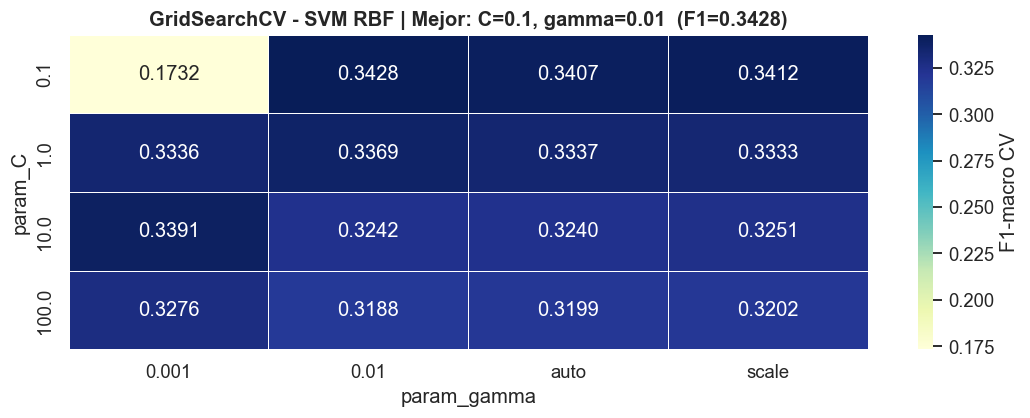

In [9]:
# Evaluación del modelo SVM tuneado
t0 = time.time()
svm_best = gs_svm.best_estimator_
yp_best_tr = svm_best.predict(X_train_svm)
yp_best_te = svm_best.predict(X_test_sc)
t_best = time.time() - t0

acc_best_tr = accuracy_score(y_train_svm, yp_best_tr)
acc_best_te = accuracy_score(y_test_c,    yp_best_te)
f1_best_te  = f1_score(y_test_c, yp_best_te, average='macro')
f1_best_w   = f1_score(y_test_c, yp_best_te, average='weighted')

print(f"  SVM TUNEADO  {gs_svm.best_params_}")
print(f"  Accuracy TRAIN      : {acc_best_tr:.4f}")
print(f"  Accuracy TEST       : {acc_best_te:.4f}")
print(f"  Gap (train-test)    : {acc_best_tr - acc_best_te:.4f}")
print(f"  F1-macro TEST       : {f1_best_te:.4f}")
print(f"  F1-weighted TEST    : {f1_best_w:.4f}")
print()
print(classification_report(y_test_c, yp_best_te, target_names=le.classes_, digits=4))

# Gráfico de búsqueda
fig, ax = plt.subplots(figsize=(10, 4))
pivot = res_df.pivot_table(
    index='param_C', columns='param_gamma', values='mean_test_score')
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax,
            linewidths=0.5, cbar_kws={'label':'F1-macro CV'})
ax.set_title(f'GridSearchCV - SVM RBF | Mejor: C={gs_svm.best_params_["C"]}, '
             f'gamma={gs_svm.best_params_["gamma"]}  (F1={gs_svm.best_score_:.4f})',
             fontweight='bold')
plt.tight_layout(); plt.show()


## Matrices de Confusión y Análisis de Errores

Las matrices de confusión revelan **dónde** se equivoca cada modelo, no sólo cuánto. En clasificación multiclase, los errores de frontera (Intermedio → Caro o Intermedio → Económico) son especialmente informativos: señalan la zona del mercado donde el precio es más ambiguo y donde SmartStay debe actuar con mayor cautela al recomendar propiedades.

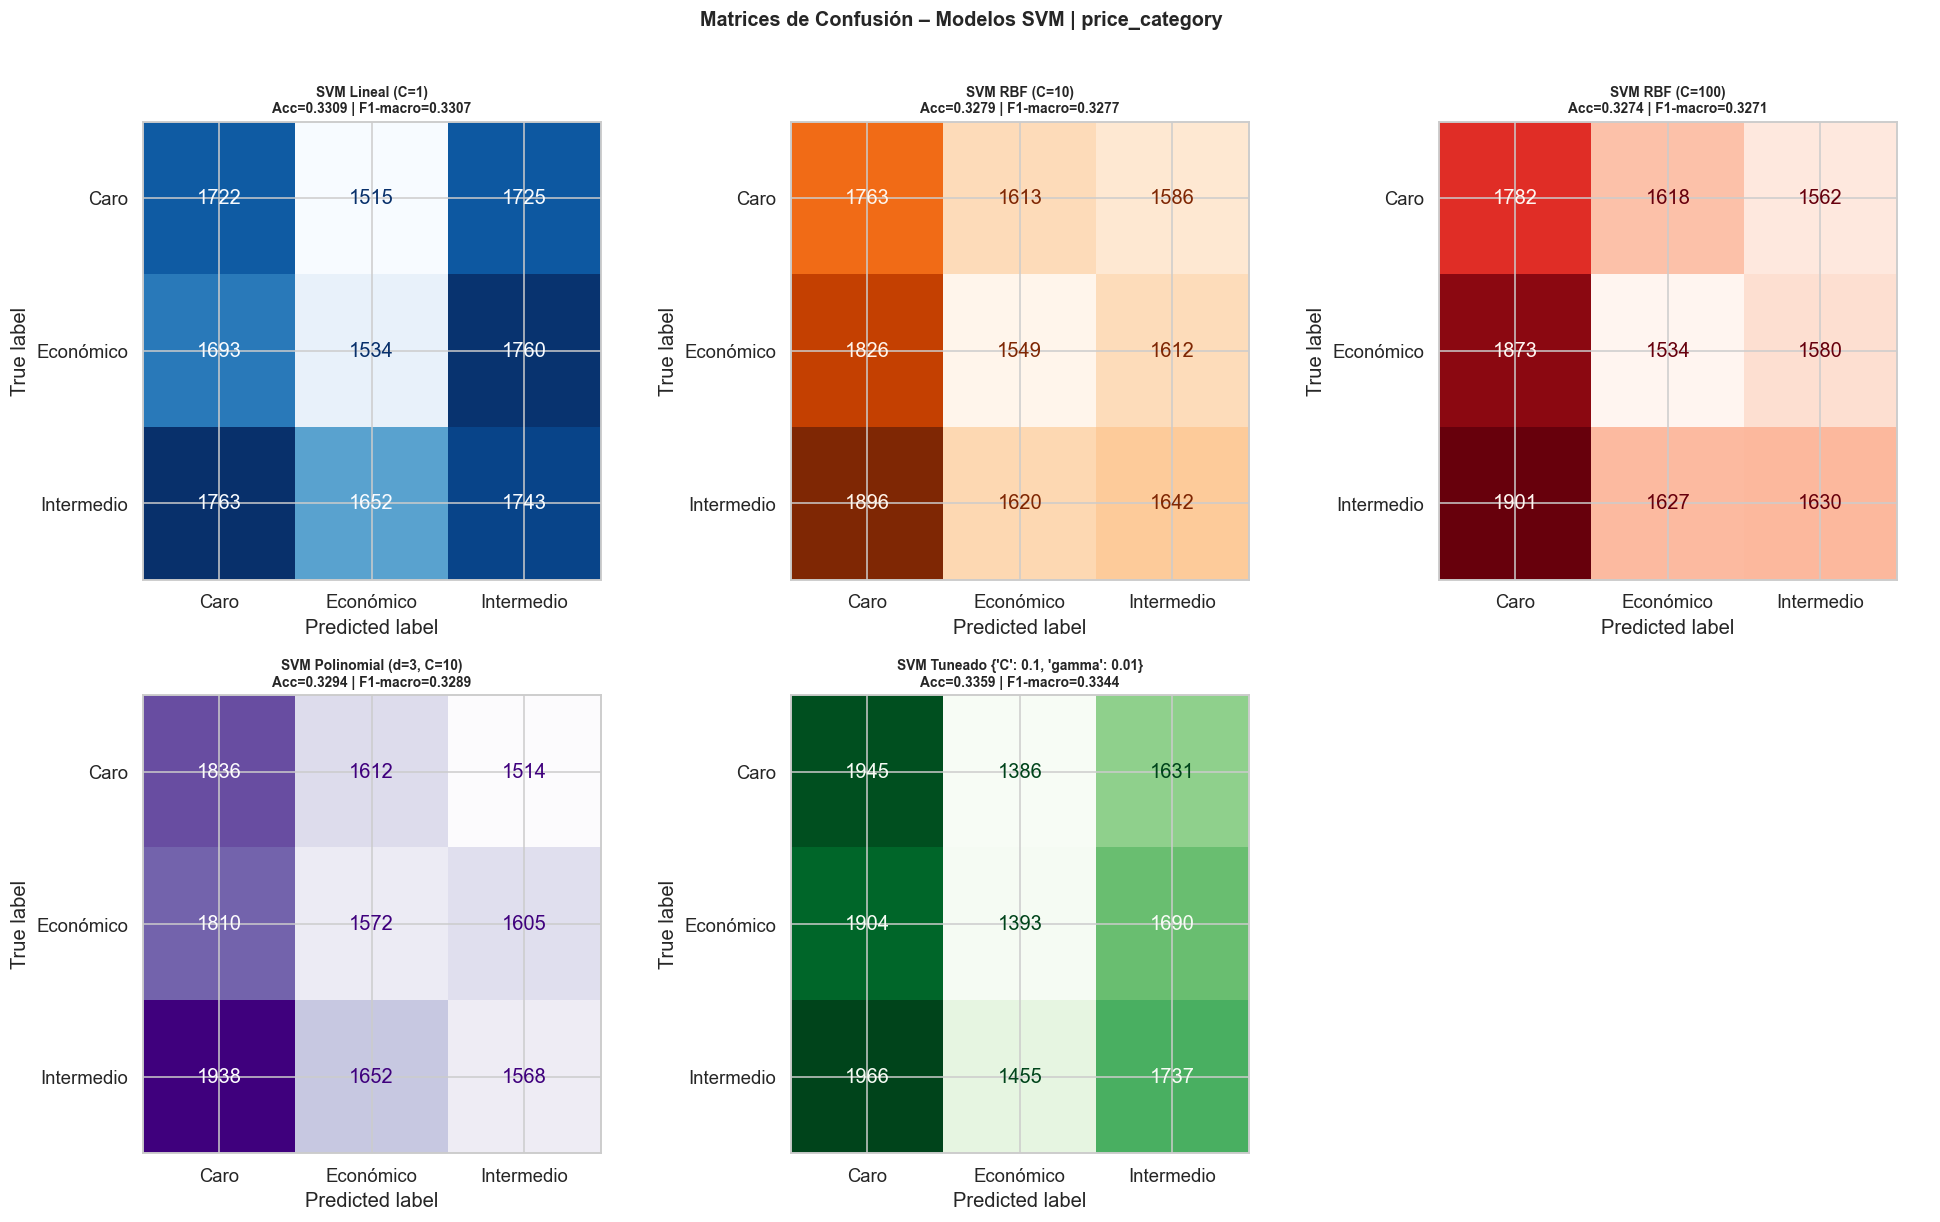

In [10]:
# Matrices de confusión — 4 modelos + tuneado
modelos_svm = [
    ('SVM Lineal (C=1)',              yp_lin_te,   acc_lin_te,   f1_lin_te,  'Blues'),
    ('SVM RBF (C=10)',                yp_rbf_te,   acc_rbf_te,   f1_rbf_te,  'Oranges'),
    ('SVM RBF (C=100)',               yp_rbf100_te,acc_rbf100_te,f1_rbf100_te,'Reds'),
    ('SVM Polinomial (d=3, C=10)',    yp_poly_te,  acc_poly_te,  f1_poly_te, 'Purples'),
    (f'SVM Tuneado {gs_svm.best_params_}', yp_best_te, acc_best_te, f1_best_te, 'Greens'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat = axes.flatten()

for ax, (nombre, yp, acc, f1, cmap) in zip(axes_flat, modelos_svm):
    cm = confusion_matrix(y_test_c, yp)
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'{nombre}\nAcc={acc:.4f} | F1-macro={f1:.4f}',
                 fontweight='bold', fontsize=9)

axes_flat[-1].axis('off')  # celda vacía
plt.suptitle('Matrices de Confusión – Modelos SVM | price_category',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


In [11]:
# Análisis detallado de errores — Modelo tuneado
print("  ANÁLISIS DE ERRORES — SVM TUNEADO")
cm_best = confusion_matrix(y_test_c, yp_best_te)

total_errores = 0
for i, cls_true in enumerate(le.classes_):
    n_total = cm_best[i].sum()
    n_correcto = cm_best[i, i]
    n_error = n_total - n_correcto
    total_errores += n_error
    print(f"\n  Clase REAL: {cls_true} ({n_total} obs)")
    print(f"Correctos : {n_correcto} ({n_correcto/n_total*100:.1f}%)")
    for j, cls_pred in enumerate(le.classes_):
        if i != j and cm_best[i, j] > 0:
            pct = cm_best[i, j] / n_total * 100
            print(f"Predicho como {cls_pred:<12}: {cm_best[i,j]:>5} ({pct:.1f}%)")

print(f"\n  Total errores: {total_errores:,} / {len(y_test_c):,} ({total_errores/len(y_test_c)*100:.1f}%)")
print()
print("INTERPRETACIÓN PARA SmartStay:")
print("- Los errores Económico - Caro son graves (propiedad mal categorizada por 2 tramos)")
print("- Los errores Intermedio - adyacente son esperables (frontera difusa en el mercado)")
print("- La clase con más errores indica el segmento de precio más ambiguo")


  ANÁLISIS DE ERRORES — SVM TUNEADO

  Clase REAL: Caro (4962 obs)
Correctos : 1945 (39.2%)
Predicho como Económico   :  1386 (27.9%)
Predicho como Intermedio  :  1631 (32.9%)

  Clase REAL: Económico (4987 obs)
Correctos : 1393 (27.9%)
Predicho como Caro        :  1904 (38.2%)
Predicho como Intermedio  :  1690 (33.9%)

  Clase REAL: Intermedio (5158 obs)
Correctos : 1737 (33.7%)
Predicho como Caro        :  1966 (38.1%)
Predicho como Económico   :  1455 (28.2%)

  Total errores: 10,032 / 15,107 (66.4%)

INTERPRETACIÓN PARA SmartStay:
- Los errores Económico - Caro son graves (propiedad mal categorizada por 2 tramos)
- Los errores Intermedio - adyacente son esperables (frontera difusa en el mercado)
- La clase con más errores indica el segmento de precio más ambiguo


## Diagnóstico de Sobreajuste y Desajuste en los Modelos SVM

### ¿Qué métricas comparar para detectar overfitting en clasificación?

El sobreajuste se detecta comparando el rendimiento en los conjuntos de entrenamiento
y prueba. Las métricas clave son:

1. **Accuracy train vs. test** — indicador principal; gap > 0.05 es preocupante
2. **F1-macro train vs. test** — más robusto con clases desbalanceadas
3. **Número de vectores de soporte** — muchos SV indican frontera compleja → más riesgo
4. **Curvas de aprendizaje** — permiten ver si el modelo mejora con más datos

**Sobreajuste (overfitting):** El modelo memoriza el set de entrenamiento pero no
generaliza. **Causas en SVM:** C demasiado alto, gamma demasiado alto (influencia muy
local). **Solución:** Reducir C, reducir gamma, usar kernel más simple, añadir datos.

**Desajuste (underfitting):** El modelo es demasiado simple incluso en entrenamiento.
**Causas en SVM:** C demasiado bajo, kernel lineal en datos no lineales.
**Solución:** Aumentar C, usar kernel más complejo (linear → RBF → poly de grado mayor).


Modelo                            Train     Test      Gap      SV  Estado
  SVM Lineal (C=1)               0.3839   0.3309   0.0530       —  Bien calibrado
  SVM RBF (C=10)                 0.7383   0.3279   0.4104    7783  Sobreajuste severo
  SVM RBF (C=100)                0.9274   0.3274   0.6000    7505  Sobreajuste severo
  SVM Polinomial (d=3,C=10)      0.7872   0.3294   0.4578    7414  Sobreajuste severo
  SVM Tuneado                    0.3935   0.3359   0.0576    7996  Bien calibrado


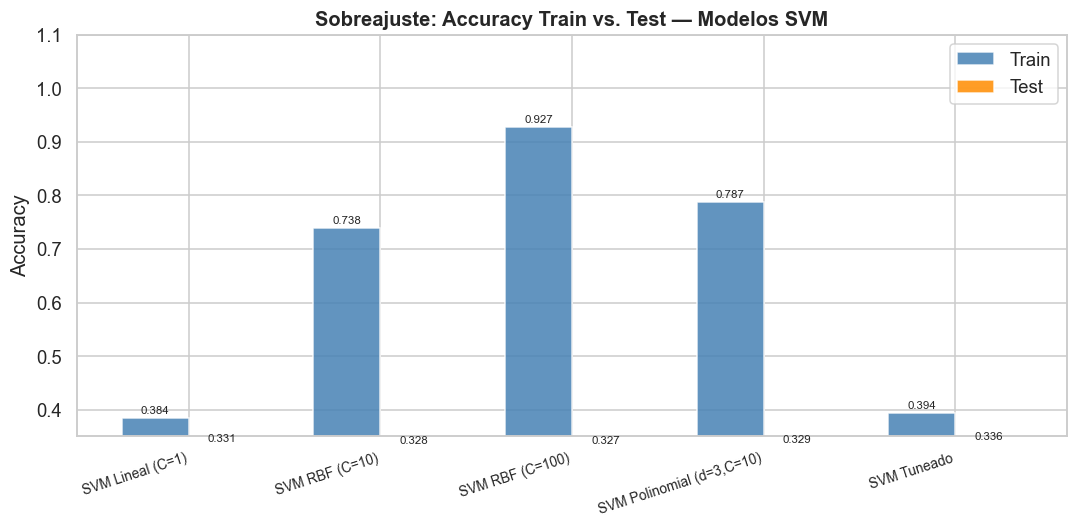

In [12]:
# Tabla de sobreajuste — modelos SVM
svm_info = [
    ('SVM Lineal (C=1)',           acc_lin_tr,   acc_lin_te,   t_lin,   '—'),
    ('SVM RBF (C=10)',             acc_rbf_tr,   acc_rbf_te,   t_rbf,   str(sum(svm_rbf.n_support_))),
    ('SVM RBF (C=100)',            acc_rbf100_tr,acc_rbf100_te,t_rbf100,str(sum(svm_rbf_c100.n_support_))),
    ('SVM Polinomial (d=3,C=10)', acc_poly_tr,  acc_poly_te,  t_poly,  str(sum(svm_poly.n_support_))),
    (f'SVM Tuneado',              acc_best_tr,  acc_best_te,  t_best,  str(sum(svm_best.n_support_))),
]

print(f"{'Modelo':<30} {'Train':>8} {'Test':>8} {'Gap':>8} {'SV':>7}  {'Estado'}")

for nombre, tr, te, t, sv in svm_info:
    gap = tr - te
    if gap > 0.12:    estado = 'Sobreajuste severo'
    elif gap > 0.06:  estado = 'Sobreajuste moderado'
    elif gap > -0.02: estado = 'Bien calibrado'
    else:             estado = 'Posible underfitting'
    print(f"  {nombre:<28} {tr:>8.4f} {te:>8.4f} {gap:>8.4f} {sv:>7}  {estado}")

# Gráfico train vs test
fig, ax = plt.subplots(figsize=(10, 5))
nombres = [m[0] for m in svm_info]
trains  = [m[1] for m in svm_info]
tests   = [m[2] for m in svm_info]
x = np.arange(len(nombres))
w = 0.35
bars1 = ax.bar(x - w/2, trains, w, label='Train', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + w/2, tests,  w, label='Test',  color='darkorange', alpha=0.85)
for bar, v in zip(list(bars1) + list(bars2), trains + tests):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.3f}',
            ha='center', va='bottom', fontsize=7.5)
ax.set_xticks(x)
ax.set_xticklabels(nombres, rotation=18, ha='right', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_ylim(0.35, 1.10)
ax.set_title('Sobreajuste: Accuracy Train vs. Test — Modelos SVM', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()


## El Mejor SVM en Perspectiva: ¿Cómo se Posiciona frente a los Algoritmos Anteriores?

Habiendo identificado la configuración óptima de SVM, el siguiente paso natural en una
consultoría de minería de datos es contrastar su rendimiento con todos los algoritmos
entrenados en Labs anteriores bajo la **misma variable respuesta y el mismo conjunto de prueba**.
Esta comparación es el corazón del análisis comparativo que permite a SmartStay elegir
el modelo más adecuado para producción.

Todos los algoritmos de Labs 4–7 se re-entrenan con los hiperparámetros tuneados
anteriormente. SVM se mantiene con la muestra de 8,000 observaciones, hecho que se
documenta en la tabla y que debe tenerse en cuenta al interpretar los resultados.


In [13]:
# Re-entrenamiento de modelos anteriores (mismas condiciones)
# Todos se entrenan sobre X_train_c COMPLETO y se evalúan en X_test_c COMPLETO.
# SVM usa muestra de 8,000 obs — diferencia documentada en tabla.

# Random Forest
t0 = time.time()
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=10,
    min_samples_leaf=5, max_features='sqrt', class_weight='balanced',
    random_state=42, n_jobs=-1)
rf_clf.fit(X_train_c, y_train_c)
yp_rf = rf_clf.predict(X_test_c)
acc_rf_tr = accuracy_score(y_train_c, rf_clf.predict(X_train_c))
t_rf = time.time() - t0

# Árbol de decisión
t0 = time.time()
tree_clf = DecisionTreeClassifier(max_depth=15, min_samples_split=10,
    class_weight='balanced', random_state=42)
tree_clf.fit(X_train_c, y_train_c)
yp_tree = tree_clf.predict(X_test_c)
acc_tree_tr = accuracy_score(y_train_c, tree_clf.predict(X_train_c))
t_tree = time.time() - t0

# Naive Bayes
t0 = time.time()
nb_clf = GaussianNB(var_smoothing=1e-9)
nb_clf.fit(X_train_c, y_train_c)
yp_nb = nb_clf.predict(X_test_c)
acc_nb_tr = accuracy_score(y_train_c, nb_clf.predict(X_train_c))
t_nb = time.time() - t0

# KNN (escalado obligatorio)
X_tr_sc_c = scaler.fit_transform(X_train_c)
X_te_sc_c = scaler.transform(X_test_c)
t0 = time.time()
knn_clf = KNeighborsClassifier(n_neighbors=11, p=1, weights='distance', n_jobs=-1)
knn_clf.fit(X_tr_sc_c, y_train_c)
yp_knn = knn_clf.predict(X_te_sc_c)
acc_knn_tr = accuracy_score(y_train_c, knn_clf.predict(X_tr_sc_c))
t_knn = time.time() - t0

# Regresión Logística
t0 = time.time()
lr_clf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced',
    solver='lbfgs', random_state=42)
lr_clf.fit(X_tr_sc_c, y_train_c)
yp_lr = lr_clf.predict(X_te_sc_c)
acc_lr_tr = accuracy_score(y_train_c, lr_clf.predict(X_tr_sc_c))
t_lr = time.time() - t0

print("Modelos de Labs anteriores re-entrenados.")


Modelos de Labs anteriores re-entrenados.


In [14]:
# Tabla comparativa final — clasificación multiclase
clf_all = [
    ('Random Forest (n=200,d=15)', yp_rf,       acc_rf_tr,   t_rf,   'Completo 60K'),
    ('SVM Tuneado (RBF)',          yp_best_te,  acc_best_tr, t_best, 'Muestra 8K'),
    ('KNN (K=11, Manhattan)',      yp_knn,      acc_knn_tr,  t_knn,  'Completo 60K'),
    ('Árbol (depth=15)',           yp_tree,     acc_tree_tr, t_tree, 'Completo 60K'),
    ('Regresión Logística',        yp_lr,       acc_lr_tr,   t_lr,   'Completo 60K'),
    ('Naive Bayes',                yp_nb,       acc_nb_tr,   t_nb,   'Completo 60K'),
    ('SVM Lineal (C=1)',           yp_lin_te,   acc_lin_tr,  t_lin,  'Muestra 8K'),
    ('SVM RBF (C=10)',             yp_rbf_te,   acc_rbf_tr,  t_rbf,  'Muestra 8K'),
    ('SVM Polinomial (d=3)',       yp_poly_te,  acc_poly_tr, t_poly, 'Muestra 8K'),
]

rows = []
for nombre, yp, tr_acc, tiempo, ts in clf_all:
    te_acc = accuracy_score(y_test_c, yp)
    rows.append({
        'Modelo': nombre,
        'Acc.Test': round(te_acc, 4),
        'F1-macro': round(f1_score(y_test_c, yp, average='macro'), 4),
        'F1-weighted': round(f1_score(y_test_c, yp, average='weighted'), 4),
        'Acc.Train': round(tr_acc, 4),
        'Gap': round(tr_acc - te_acc, 4),
        'Tiempo(s)': round(tiempo, 3),
        'Train set': ts,
    })

df_clf = pd.DataFrame(rows).sort_values('F1-macro', ascending=False).reset_index(drop=True)
print("  COMPARACIÓN FINAL - CLASIFICACIÓN MULTICLASE (mismo X_test, random_state=42)")
print(df_clf.to_string(index=False))
print()
print(f"Mejor modelo: {df_clf.iloc[0]['Modelo']}  (F1-macro={df_clf.iloc[0]['F1-macro']:.4f})")
print(f"Más lento   : {df_clf.loc[df_clf['Tiempo(s)'].idxmax(),'Modelo']}")
print(f"Más rápido  : {df_clf.loc[df_clf['Tiempo(s)'].idxmin(),'Modelo']}")


  COMPARACIÓN FINAL - CLASIFICACIÓN MULTICLASE (mismo X_test, random_state=42)
                    Modelo  Acc.Test  F1-macro  F1-weighted  Acc.Train     Gap  Tiempo(s)    Train set
Random Forest (n=200,d=15)    0.7510    0.7516       0.7505     0.8463  0.0953      4.796 Completo 60K
     KNN (K=11, Manhattan)    0.7116    0.7137       0.7126     0.9999  0.2883     99.545 Completo 60K
          Árbol (depth=15)    0.7087    0.7102       0.7090     0.8408  0.1321      1.382 Completo 60K
       Regresión Logística    0.6655    0.6639       0.6624     0.6662  0.0007      1.153 Completo 60K
         SVM Tuneado (RBF)    0.3359    0.3344       0.3344     0.3935  0.0576     16.907   Muestra 8K
          SVM Lineal (C=1)    0.3309    0.3307       0.3307     0.3839  0.0530      0.546   Muestra 8K
      SVM Polinomial (d=3)    0.3294    0.3289       0.3288     0.7872  0.4578     54.639   Muestra 8K
            SVM RBF (C=10)    0.3279    0.3277       0.3277     0.7383  0.4104     30.702   Muest

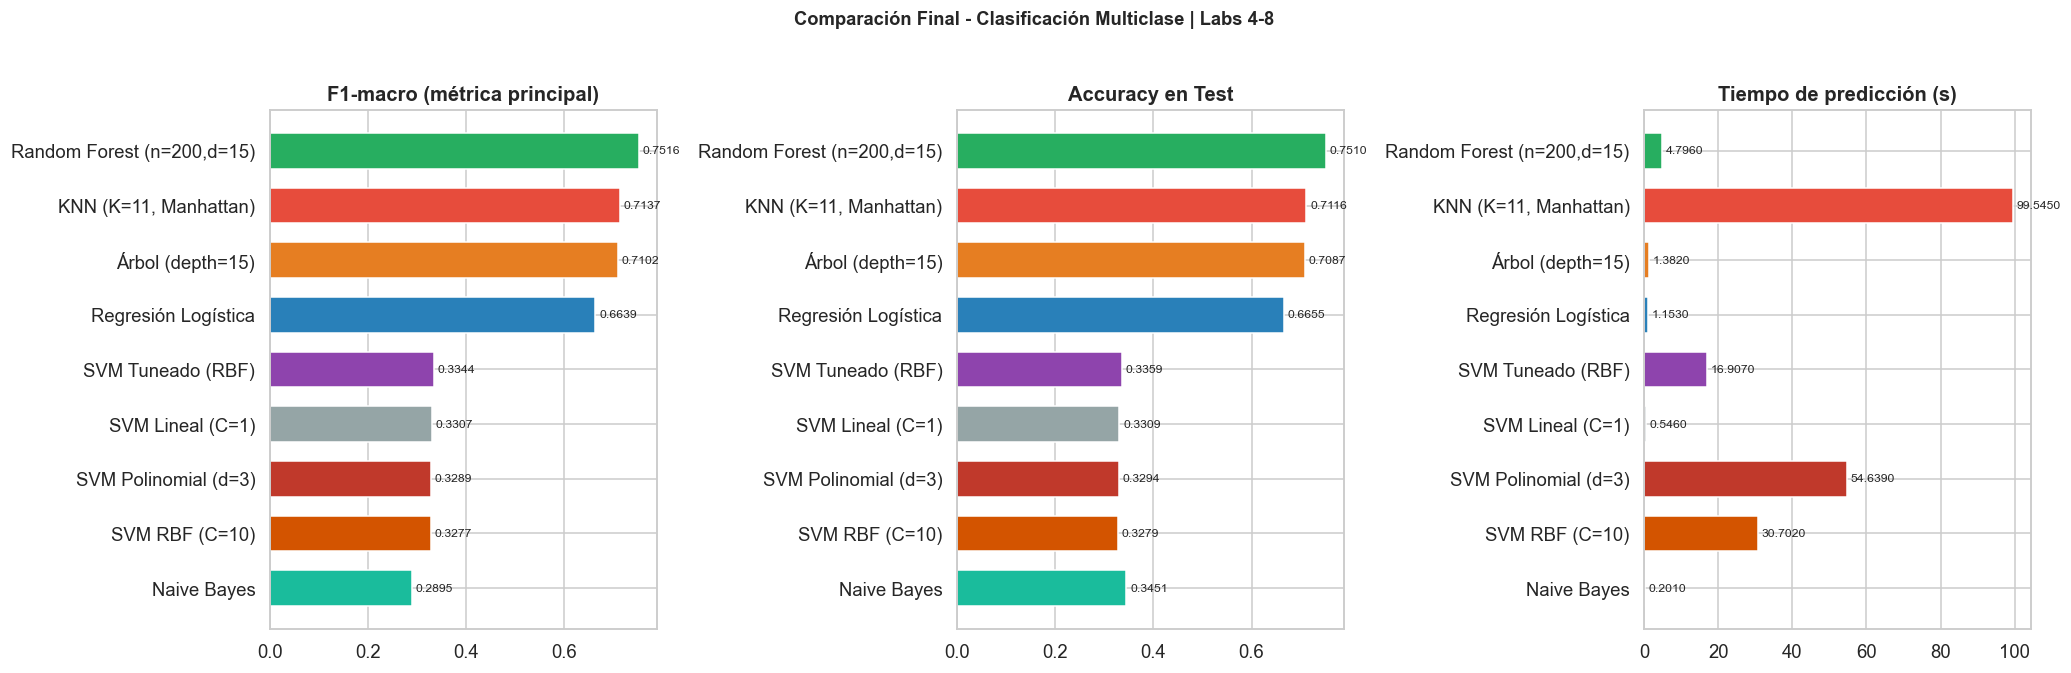

In [15]:
# Visualización comparativa de clasificación
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
palette = ['#27ae60','#e74c3c','#e67e22','#2980b9','#8e44ad',
           '#95a5a6','#c0392b','#d35400','#1abc9c']

for ax, (metric, title) in zip(axes, [
    ('F1-macro',  'F1-macro (métrica principal)'),
    ('Acc.Test',  'Accuracy en Test'),
    ('Tiempo(s)', 'Tiempo de predicción (s)'),
]):
    bars = ax.barh(df_clf['Modelo'], df_clf[metric],
                   color=palette[:len(df_clf)], edgecolor='white', height=0.65)
    ax.invert_yaxis()
    ax.set_title(title, fontweight='bold')
    for bar, v in zip(bars, df_clf[metric]):
        ax.text(v + max(df_clf[metric]) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Comparación Final - Clasificación Multiclase | Labs 4-8',
             fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()
